# RVAE_KEy V13 — Latent Space Evaluation

**Model**: `checkpoints/rvae_key_v13/best.pt`

**Hyperparams**:
- `latent_dim=32, condition_dim=16, z_only_decoder=True`
- `beta=0.05, per_dim_free_bits=0.05, kl_warmup=8`
- `lambda_c_pred=10.0, lambda_key_pred=0.5`
- `tf_start=0.5, tf_end=0.0, tf_epochs=10`
- `word_dropout=0.7`

**Training issue**: β=0 at epoch 1 caused KL explosion (~784 nats) and posterior collapse (only 1 active dim).

**Goals**:
1. Verificar que el decoder sigue usando z (bypass test)
2. Analizar espacio latente: dims activas, KL, correlaciones
3. Ver si hay separación por key y por complejidad (C)
4. Probar control de C y key desde el prior
5. Test rápido de enrichment en progresiones simples

In [1]:
import json, sys, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.stats import pearsonr

sys.path.insert(0, str(Path('..').resolve()))
from cvae.dataset import ChordProgressionDataset, PERCEPTUAL_COLS, split_indices
from cvae.models.rvae import RVAE, per_dim_kl_rvae
from chords.chord_encoder import decode_chord, encode_chord, parse_chord
from chords.vocab import CHORD_DIM

sns.set_theme(style='whitegrid')
PLOT_DIR = Path('v13_plots')
PLOT_DIR.mkdir(exist_ok=True)
print('Imports OK')

Imports OK


In [2]:
LATENT_DIM = 32
CONDITION_DIM = 16
CHECKPOINT_PATH = '/home/pepebeats/SCL_2.0/checkpoints/rvae_key_v13/best.pt'
N_SAMPLES = 10000
MAX_LEN = 128
KEY_NAMES = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [3]:
model = RVAE(latent_dim=LATENT_DIM, condition_dim=CONDITION_DIM, z_only_decoder=True).to(device)
ckpt = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
epoch = ckpt.get('epoch', '?')
val_loss = ckpt.get('val_loss', None)
print(f'Loaded epoch {epoch}')
if val_loss is not None:
    print(f'Val loss: {val_loss:.4f}')
n_params = sum(p.numel() for p in model.parameters())
print(f'Params: {n_params:,}')

Loaded epoch 30
Val loss: 4.2376
Params: 3,145,552


In [4]:
# Load dataset and encode test set
dataset = ChordProgressionDataset(max_len=MAX_LEN, use_conditioning=True,
                                  cond_cols=PERCEPTUAL_COLS, use_key=True)
indices = split_indices(len(dataset), test_size=1000)
test_idx = indices['test']
print(f'Test set: {len(test_idx)} progressions')

Loading /home/pepebeats/SCL_2.0/Dataset/dataset_conditioned.parquet...


Loaded 877342 progressions with conditioning + key
Test set: 1000 progressions


In [5]:
@torch.no_grad()
def encode_progressions(indices, max_n=1000):
    mu_list, z_list, c_list = [], [], []
    keys_list, seqs_list, lens_list = [], [], []
    model.eval()
    for i in indices[:max_n]:
        seq, n, c = dataset[i]
        seq = seq.unsqueeze(0).to(device)
        c = c.unsqueeze(0).to(device)
        lengths = torch.tensor([n], device=device)
        mu, logvar = model.encode(seq, lengths)
        z = model.reparameterize(mu, logvar)
        key_idx = c[0, 4:].argmax().item()
        mu_list.append(mu.cpu())
        z_list.append(z.cpu())
        c_list.append(c.cpu())
        keys_list.append(key_idx)
        seqs_list.append(seq.cpu())
        lens_list.append(n)
    return (
        torch.cat(mu_list, dim=0),
        torch.cat(z_list, dim=0),
        torch.cat(c_list, dim=0),
        keys_list, seqs_list, lens_list
    )

print('Encoding test progressions...')
mu_all, z_all, c_all, keys_all, seqs_all, lens_all = encode_progressions(test_idx, max_n=1000)
c_perc = c_all[:, :4]
print(f'Encoded {len(mu_all)} progressions')

Encoding test progressions...


Encoded 1000 progressions


## 1. Decoder BYPASS Test

Comprueba si el decoder realmente usa z o la ignora.

In [6]:
print('=== 1. DECODER BYPASS TEST ===')
model.eval()
recon_losses_real, recon_losses_zero = [], []
with torch.no_grad():
    for i in range(min(50, len(test_idx))):
        seq, n, c = dataset[i]
        seq = seq.unsqueeze(0).to(device)
        c = c.unsqueeze(0).to(device)
        lengths = torch.tensor([n], device=device)
        mu, logvar = model.encode(seq, lengths)
        z = model.reparameterize(mu, logvar)
        z_dec = z if model.z_only_decoder else model._z_dec(z, c)
        logits = model.decoder(z_dec, seq, lengths, teacher_forcing_prob=0.0)
        loss_real = torch.nn.functional.binary_cross_entropy_with_logits(
            logits[:, :n], seq[:, :n]).item()
        recon_losses_real.append(loss_real)

        z_zero = torch.zeros_like(z)
        zd = z_zero if model.z_only_decoder else model._z_dec(z_zero, c)
        logits0 = model.decoder(zd, seq, lengths, teacher_forcing_prob=0.0)
        loss_zero = torch.nn.functional.binary_cross_entropy_with_logits(
            logits0[:, :n], seq[:, :n]).item()
        recon_losses_zero.append(loss_zero)

avg_real = np.mean(recon_losses_real)
avg_zero = np.mean(recon_losses_zero)
delta = avg_zero - avg_real
print(f'recon(z_real) @ tf=0: {avg_real:.4f} BCE')
print(f'recon(z=0) @ tf=0:    {avg_zero:.4f} BCE')
print(f'Δ (zero - real):       {delta:.4f}')
if delta > 0.15:
    print('✅ Decoder SÍ usa z (Δ > 0.15)')
elif delta > 0.05:
    print('⚠️  Decoder usa z débilmente (Δ > 0.05)')
else:
    print('❌ Decoder ignora z (Δ ≈ 0)')

=== 1. DECODER BYPASS TEST ===


recon(z_real) @ tf=0: 0.0702 BCE
recon(z=0) @ tf=0:    0.1328 BCE
Δ (zero - real):       0.0626
⚠️  Decoder usa z débilmente (Δ > 0.05)


## 2. Latent Space Summary

In [7]:
print('=== 2. LATENT SPACE SUMMARY ===')
kl_per_dim = per_dim_kl_rvae(mu_all, torch.zeros_like(mu_all),
                             torch.zeros_like(mu_all), torch.zeros_like(mu_all))
kl_per_dim = kl_per_dim.mean(dim=0)
total_kl = kl_per_dim.sum().item()
active_dims = (kl_per_dim > 0.01).sum().item()
z_std = z_all.std(dim=0).mean().item()
mu_std = mu_all.std(dim=0).mean().item()
logvar = (z_all.var(dim=0).log()).mean().item()

print(f'Per-dim KL range: {kl_per_dim.min().item():.4f} - {kl_per_dim.max().item():.4f}')
print(f'Total KL:         {total_kl:.4f} nats (over {LATENT_DIM} dims)')
print(f'Active dims (>0.01): {active_dims}/{LATENT_DIM}')
print(f'z mean std:       {z_std:.4f}')
print(f'mu mean std:      {mu_std:.4f}')
print(f'avg logvar:       {logvar:.4f}')

pca = PCA().fit(z_all.numpy())
cumsum = np.cumsum(pca.explained_variance_ratio_)
print(f'PCA 2 PCs: {cumsum[1]*100:.1f}%')
print(f'PCA 5 PCs: {cumsum[4]*100:.1f}%')
print(f'PCA 10 PCs: {cumsum[9]*100:.1f}%')

print('\nEvaluating predictors...')
with torch.no_grad():
    c_pred = model.c_predictor(z_all.to(device))
    c_mse = torch.nn.functional.mse_loss(c_pred.cpu(), c_perc).item()
    key_logits = model.key_predictor(z_all.to(device))
    key_acc = (key_logits.argmax(dim=-1).cpu() == torch.tensor(keys_all)).float().mean().item()
    print(f'c_predictor MSE: {c_mse:.4f}')
    print(f'key_predictor acc: {key_acc*100:.1f}%')

=== 2. LATENT SPACE SUMMARY ===
Per-dim KL range: 0.1224 - 3.3940
Total KL:         32.7222 nats (over 32 dims)
Active dims (>0.01): 32/32
z mean std:       1.1271
mu mean std:      0.9756
avg logvar:       0.1151
PCA 2 PCs: 41.7%
PCA 5 PCs: 65.3%
PCA 10 PCs: 83.8%

Evaluating predictors...
c_predictor MSE: 0.0034
key_predictor acc: 98.4%


## 3. PCA — Colored by Complexity (C) and Key

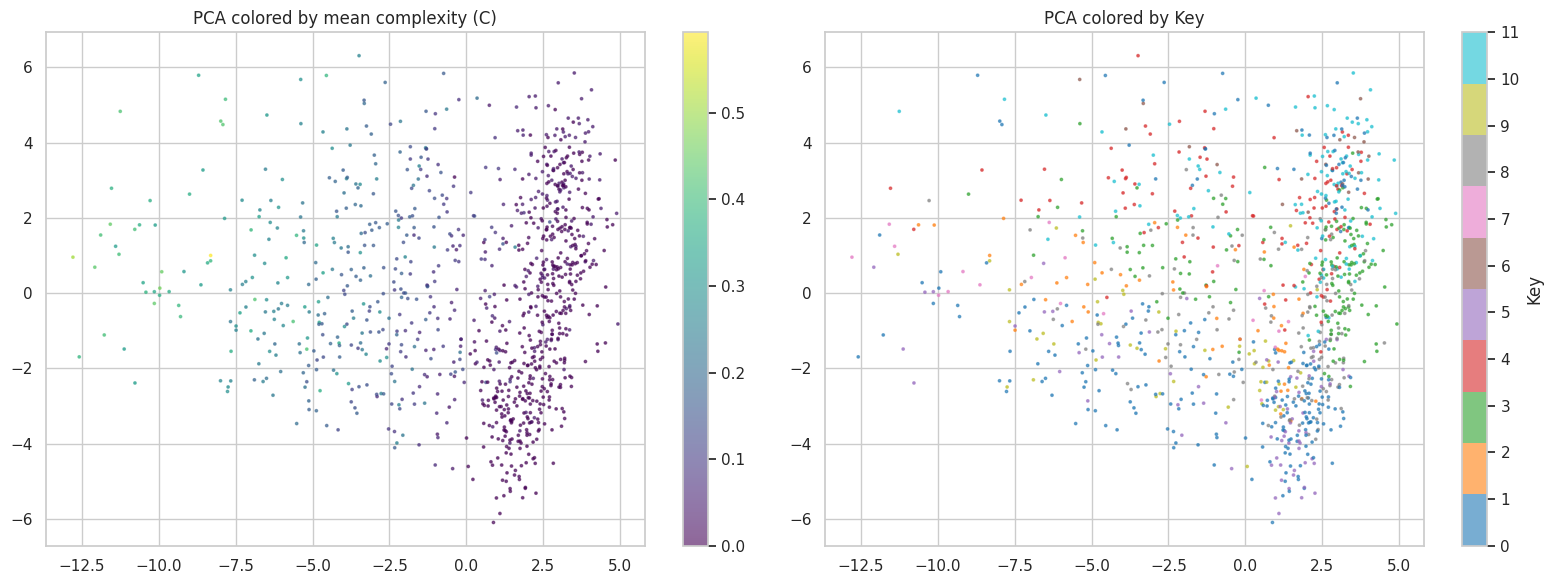

In [8]:
z_np = z_all.numpy()
pca2 = PCA(n_components=2)
z_pca = pca2.fit_transform(z_np)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sc = axes[0].scatter(z_pca[:, 0], z_pca[:, 1], c=c_perc.mean(dim=1), cmap='viridis', s=3, alpha=0.6)
axes[0].set_title('PCA colored by mean complexity (C)')
plt.colorbar(sc, ax=axes[0])

sc2 = axes[1].scatter(z_pca[:, 0], z_pca[:, 1], c=keys_all, cmap='tab10', s=3, alpha=0.6)
axes[1].set_title('PCA colored by Key')
plt.colorbar(sc2, ax=axes[1], ticks=range(12), label='Key')

plt.tight_layout()
plt.savefig(PLOT_DIR / '01_pca_colored.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. PCA — Each Perceptual Dimension Separately

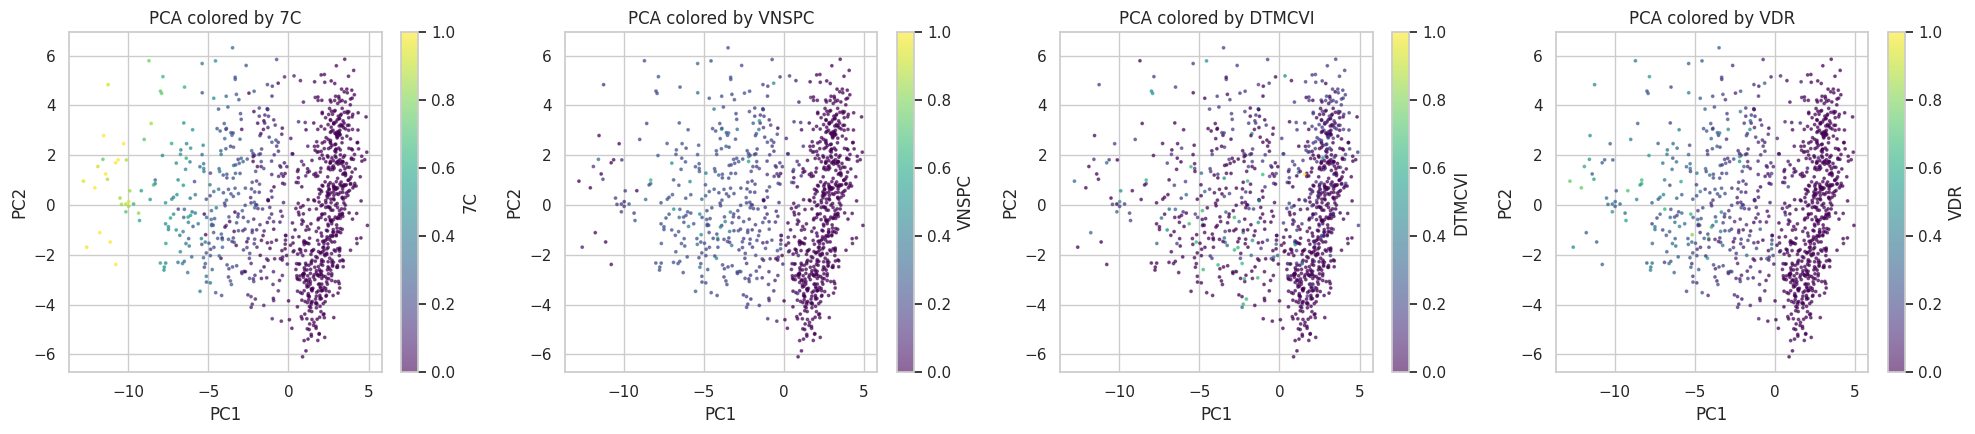

In [9]:
dim_names = ['7C', 'VNSPC', 'DTMCVI', 'VDR']
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for d, ax in enumerate(axes):
    sc = ax.scatter(z_pca[:, 0], z_pca[:, 1], c=c_perc[:, d],
                    cmap='viridis', s=3, alpha=0.6, vmin=0, vmax=1)
    ax.set_title(f'PCA colored by {dim_names[d]}')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    plt.colorbar(sc, ax=ax, label=dim_names[d])
plt.tight_layout()
plt.savefig(PLOT_DIR / '02_pca_perceptual_dims.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. PCA — Key Separation (one subplot per key)

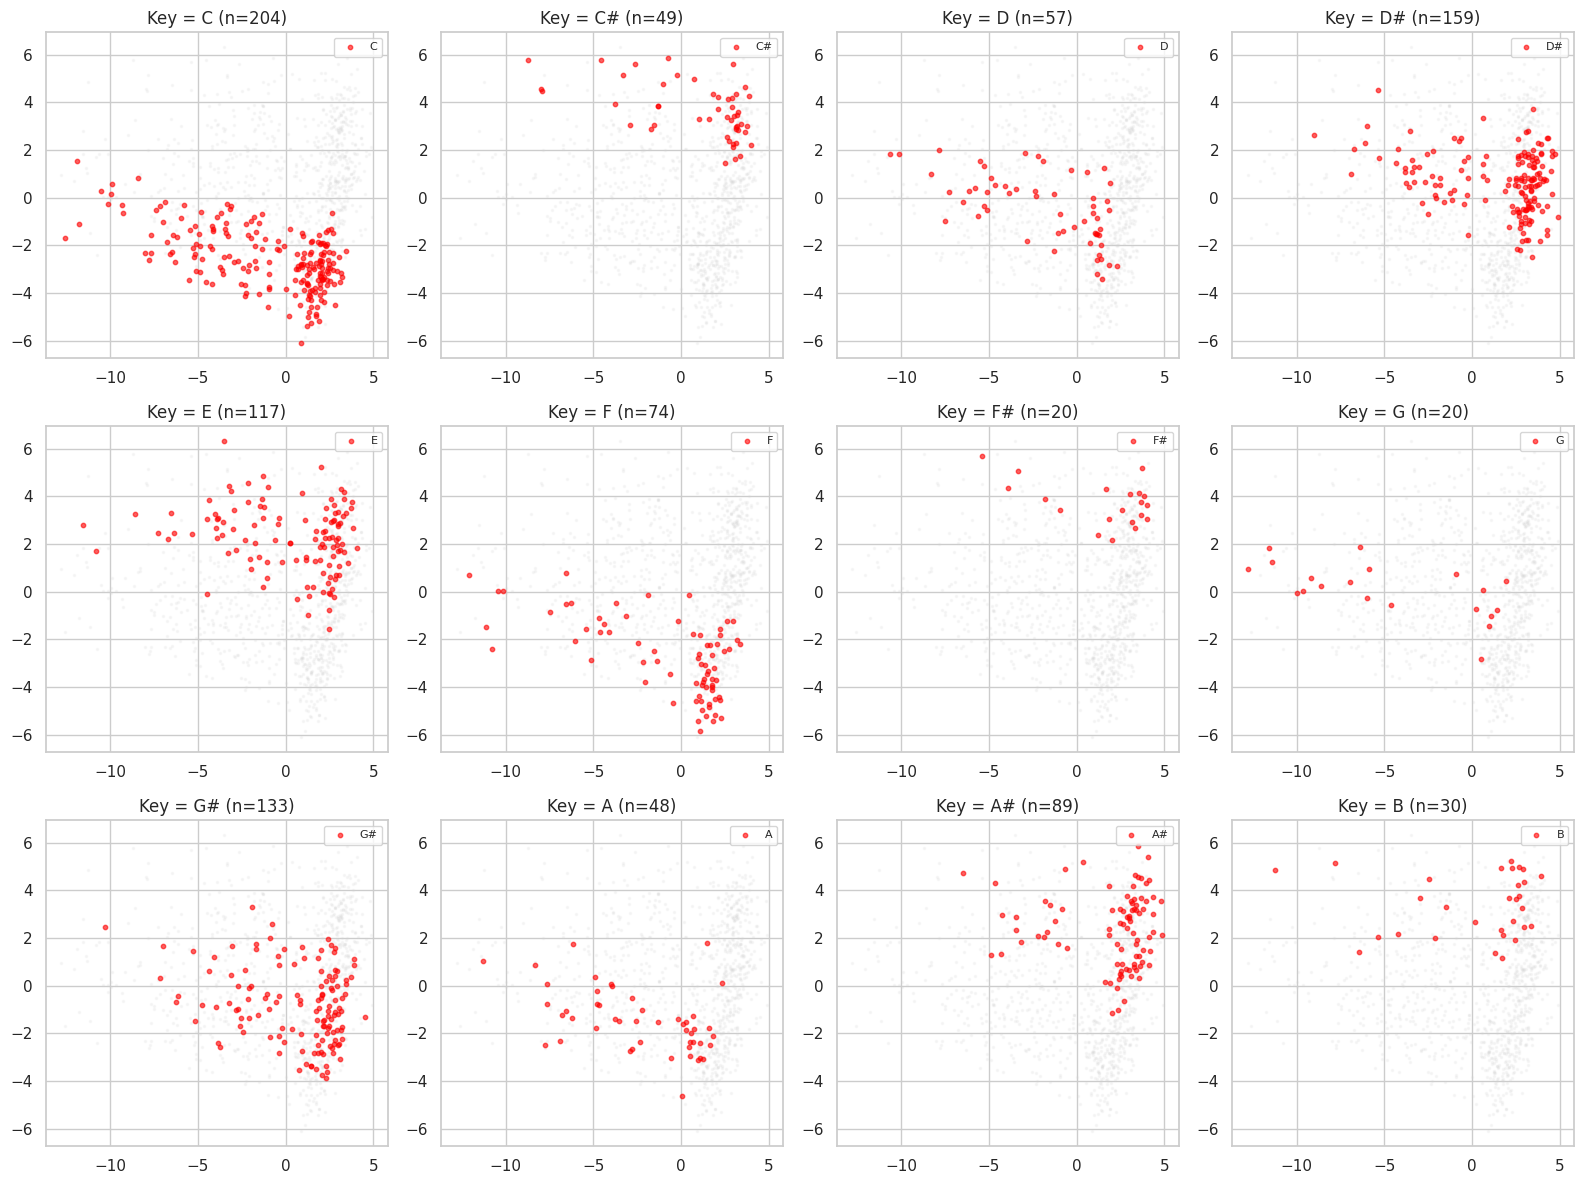

In [10]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for idx, (ax, key_name) in enumerate(zip(axes.flatten(), KEY_NAMES)):
    mask = [k == idx for k in keys_all]
    ax.scatter(z_pca[:, 0], z_pca[:, 1], c='lightgray', alpha=0.15, s=2)
    if sum(mask) > 5:
        ax.scatter(z_pca[:, 0][mask], z_pca[:, 1][mask], c='red', alpha=0.6, s=10, label=key_name)
    ax.set_title(f'Key = {key_name} (n={sum(mask)})')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(PLOT_DIR / '03_pca_key_separate.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. t-SNE — Colored by Complexity and Key

Running t-SNE on 800 samples...


t-SNE done


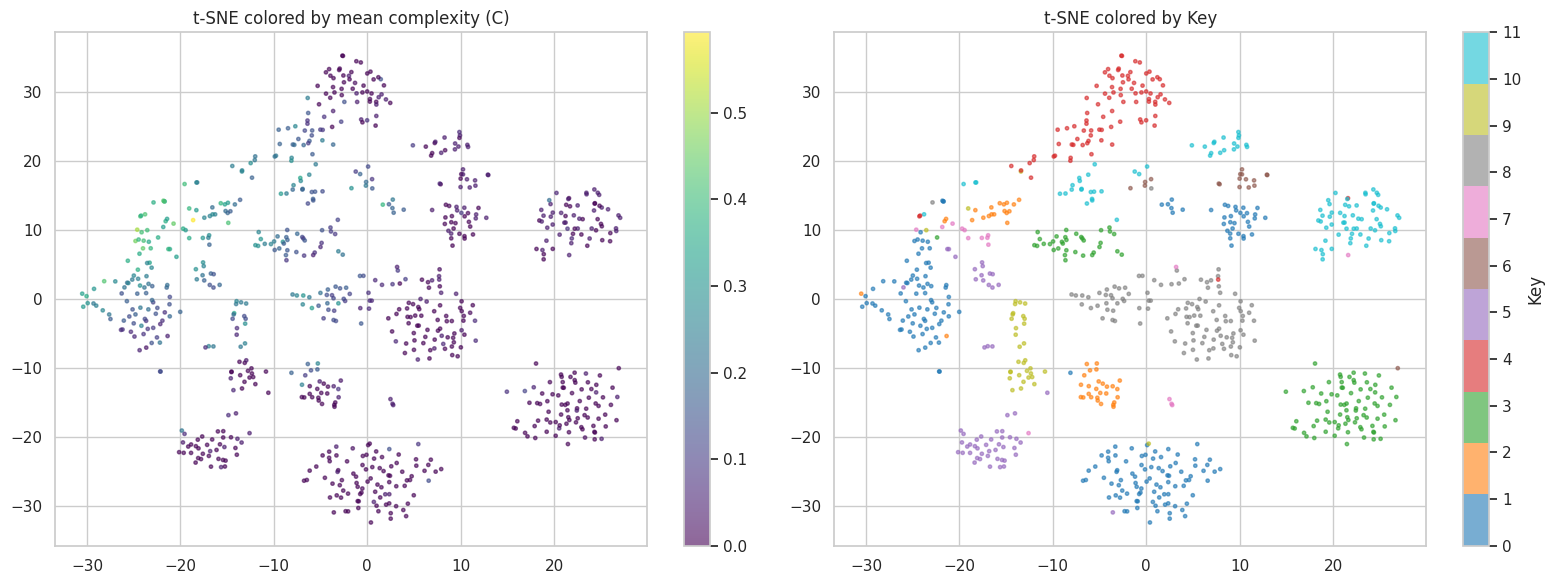

In [11]:
N_TSNE = 800
print(f'Running t-SNE on {N_TSNE} samples...')
tsne = TSNE(n_components=2, perplexity=30, max_iter=800, random_state=42)
z_tsne = tsne.fit_transform(z_np[:N_TSNE])
print('t-SNE done')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sc = axes[0].scatter(z_tsne[:, 0], z_tsne[:, 1],
                     c=c_perc[:N_TSNE].mean(dim=1), cmap='viridis', s=6, alpha=0.6)
axes[0].set_title('t-SNE colored by mean complexity (C)')
plt.colorbar(sc, ax=axes[0])

sc2 = axes[1].scatter(z_tsne[:, 0], z_tsne[:, 1],
                      c=[keys_all[i] for i in range(N_TSNE)], cmap='tab10', s=6, alpha=0.6)
axes[1].set_title('t-SNE colored by Key')
plt.colorbar(sc2, ax=axes[1], ticks=range(12), label='Key')

plt.tight_layout()
plt.savefig(PLOT_DIR / '04_tsne_colored.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Per-dimension KL and Std

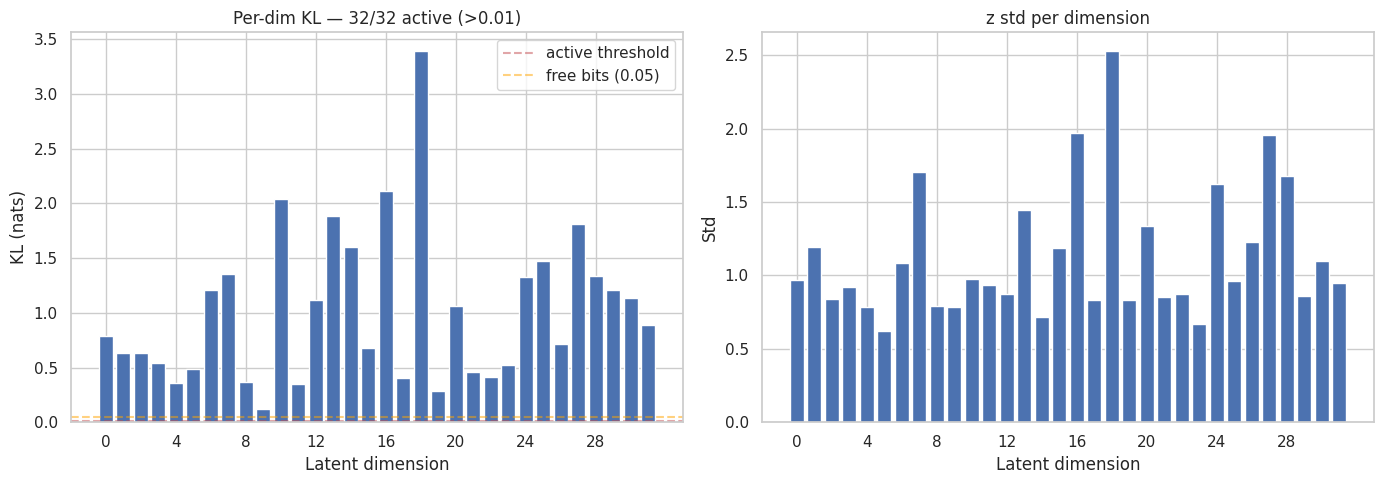

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

kl_np = kl_per_dim.numpy()
axes[0].bar(range(LATENT_DIM), kl_np)
axes[0].axhline(0.01, color='r', linestyle='--', alpha=0.5, label='active threshold')
axes[0].axhline(0.05, color='orange', linestyle='--', alpha=0.5, label='free bits (0.05)')
axes[0].set_xlabel('Latent dimension')
axes[0].set_ylabel('KL (nats)')
axes[0].set_title(f'Per-dim KL — {active_dims}/{LATENT_DIM} active (>0.01)')
axes[0].legend()
axes[0].set_xticks(range(0, LATENT_DIM, 4))

z_std_per_dim = z_all.std(dim=0).numpy()
axes[1].bar(range(LATENT_DIM), z_std_per_dim)
axes[1].set_xlabel('Latent dimension')
axes[1].set_ylabel('Std')
axes[1].set_title('z std per dimension')
axes[1].set_xticks(range(0, LATENT_DIM, 4))

plt.tight_layout()
plt.savefig(PLOT_DIR / '05_per_dim_kl_std.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Latent Correlation Matrix (z × z)

Inter-z |r| mean: 0.2683
Inter-z |r| max:  0.8742
|r|>0.3: 38.5%


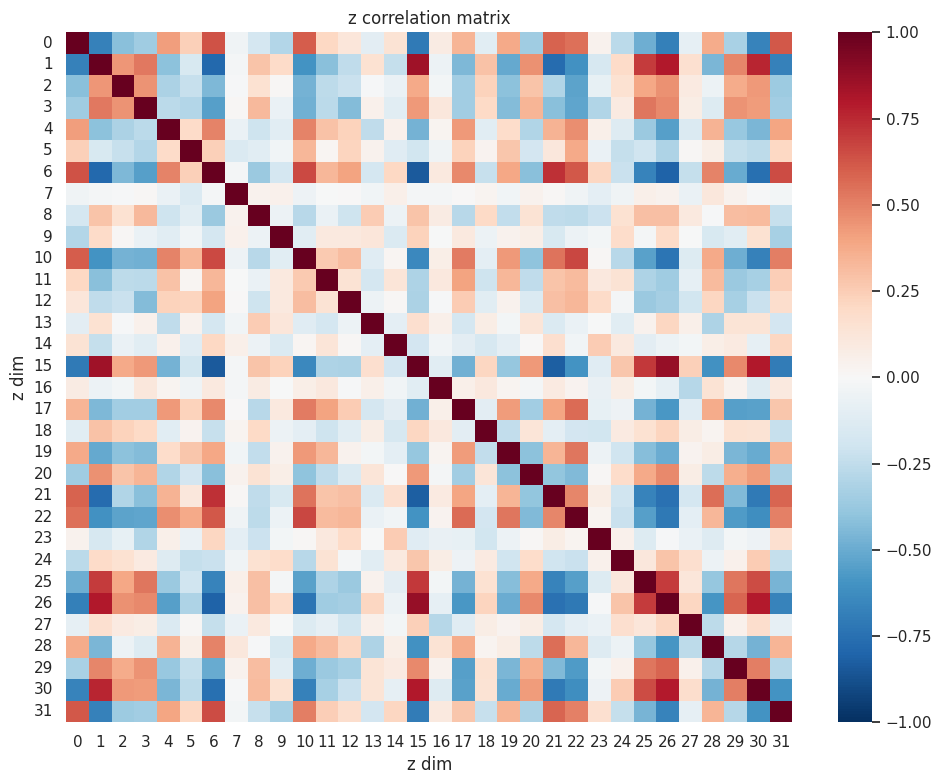

In [ ]:
z_corr = np.corrcoef(z_np.T)
off_diag = np.triu(z_corr, k=1)[np.triu(np.ones_like(z_corr), k=1).astype(bool)]
print(f'Inter-z |r| mean: {np.abs(off_diag).mean():.4f}')
print(f'Inter-z |r| max:  {np.abs(off_diag).max():.4f}')
print(f'|r|>0.3: {(np.abs(off_diag)>0.3).mean()*100:.1f}%')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(z_corr, cmap='RdBu_r', vmin=-1, vmax=1, center=0, ax=ax)
ax.set_title('z correlation matrix')
ax.set_xlabel('z dim'); ax.set_ylabel('z dim')
plt.tight_layout()
plt.savefig(PLOT_DIR / '06_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Correlation of each dim with Complexity (C)

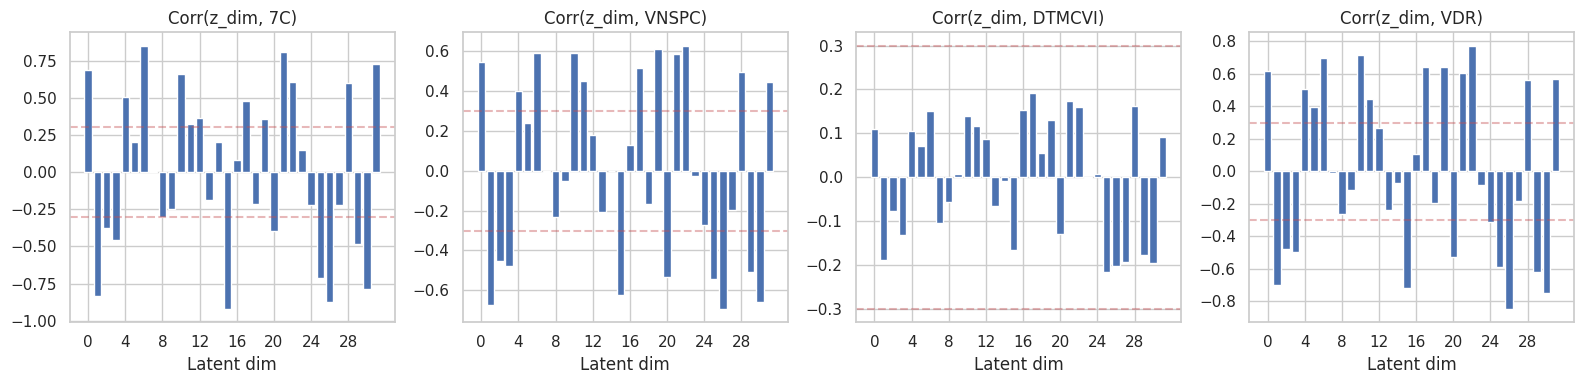

Top correlations per C-dim:
  7C: [('z15', np.float64(-0.922)), ('z26', np.float64(-0.877)), ('z6', np.float64(0.851)), ('z1', np.float64(-0.834)), ('z21', np.float64(0.81))]
  VNSPC: [('z26', np.float64(-0.694)), ('z1', np.float64(-0.671)), ('z30', np.float64(-0.659)), ('z22', np.float64(0.628)), ('z15', np.float64(-0.622))]
  DTMCVI: [('z25', np.float64(-0.215)), ('z26', np.float64(-0.202)), ('z30', np.float64(-0.195)), ('z27', np.float64(-0.192)), ('z17', np.float64(0.192))]
  VDR: [('z26', np.float64(-0.849)), ('z22', np.float64(0.774)), ('z30', np.float64(-0.747)), ('z15', np.float64(-0.722)), ('z10', np.float64(0.715))]


In [14]:
c_names = ['7C', 'VNSPC', 'DTMCVI', 'VDR']
c_corr = np.zeros((LATENT_DIM, 4))
for d in range(4):
    for l in range(LATENT_DIM):
        c_corr[l, d] = np.corrcoef(z_np[:, l], c_perc[:, d].numpy())[0, 1]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for d in range(4):
    axes[d].bar(range(LATENT_DIM), c_corr[:, d])
    axes[d].set_title(f'Corr(z_dim, {c_names[d]})')
    axes[d].set_xlabel('Latent dim')
    axes[d].axhline(0.3, color='r', linestyle='--', alpha=0.4)
    axes[d].axhline(-0.3, color='r', linestyle='--', alpha=0.4)
    axes[d].set_xticks(range(0, LATENT_DIM, 4))
plt.tight_layout()
plt.savefig(PLOT_DIR / '07_c_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top correlations per C-dim:')
for d in range(4):
    top = sorted([(l, c_corr[l,d]) for l in range(LATENT_DIM)],
                key=lambda x: abs(x[1]), reverse=True)[:5]
    print(f'  {c_names[d]}: {[(f"z{l}", round(v,3)) for l,v in top]}')

## 10. ||z|| Norm Distribution

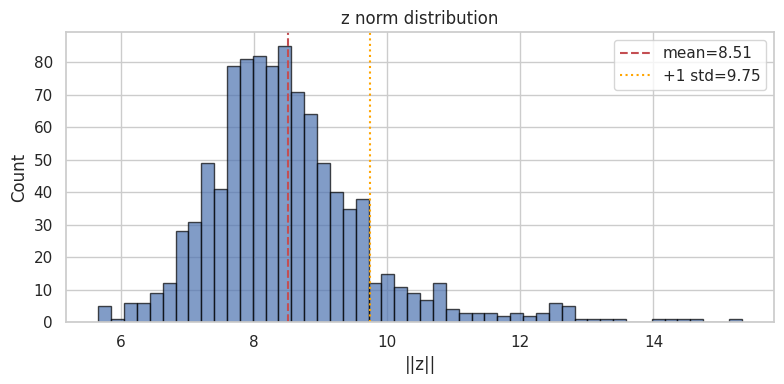

In [15]:
z_norm = np.linalg.norm(z_np, axis=1)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(z_norm, bins=50, alpha=0.7, edgecolor='black')
ax.axvline(z_norm.mean(), color='r', linestyle='--', label=f'mean={z_norm.mean():.2f}')
ax.axvline(z_norm.mean() + z_norm.std(), color='orange', linestyle=':', label=f'+1 std={z_norm.mean()+z_norm.std():.2f}')
ax.set_xlabel('||z||')
ax.set_ylabel('Count')
ax.set_title('z norm distribution')
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / '08_z_norm_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. C Control Test (Complexity Interpolation)

In [16]:
print('=== 11. C CONTROL TEST ===')
model.eval()
example_idx = test_idx[0]
seq, n, c = dataset[example_idx]
seq = seq.unsqueeze(0).to(device)
c = c.unsqueeze(0).to(device)
lengths = torch.tensor([n], device=device)

with torch.no_grad():
    mu, logvar = model.encode(seq, lengths)
    z = model.reparameterize(mu, logvar)

key_onehot = c[0, 4:].clone()
key_name = KEY_NAMES[key_onehot.argmax().item()]

print(f'Original: {n} chords')
orig_chords = [decode_chord(seq[0, t].cpu().numpy()) for t in range(min(n, 16))]
print(f'Original: {" | ".join(orig_chords)}')
print(f'Original C: {c[0, :4].cpu().numpy()}, key={key_name}')

c_vals = [0.0, 0.25, 0.5, 0.75, 1.0]
print()
for frac in c_vals:
    c_perc_new = torch.full((1, 4), frac, device=device)
    c_new = torch.cat([c_perc_new, key_onehot.unsqueeze(0)], dim=-1)
    with torch.no_grad():
        gen_seq = model.generate(z, c_new, max_len=n, device=device)
    gen_chords = [decode_chord(gen_seq[0, t].cpu().numpy()) for t in range(min(n, 16))]
    n_notes = sum(1 for ch in gen_chords if ch != 'N.C.')
    n_7ths = sum(1 for ch in gen_chords if '7' in ch)
    n_exts = sum(1 for ch in gen_chords if any(e in ch for e in ['9', '11', '13']))
    print(f'C={frac:.2f}: notes/step={n_notes/min(n,16):.2f} 7ths={n_7ths} exts={n_exts}')
    print(f'  {" | ".join(gen_chords)}')

=== 11. C CONTROL TEST ===
Original: 58 chords
Original: A# | F | C | Dm | F | C | A# | F | A# | Dm | C | F | C | F | A# | F
Original C: [0. 0. 0. 0.], key=C



C=0.00: notes/step=1.00 7ths=0 exts=0
  C | C | D# | C | D# | D# | D# | A#m | D# | C | C | D | D# | D | A# | E
C=0.25: notes/step=1.00 7ths=0 exts=0
  F | D# | C | Dm | G# | A# | A# | Fm | D#m | D | F# | C | C | Cm | C | D


C=0.50: notes/step=1.00 7ths=0 exts=0
  A# | C | D | E | G# | E | C | D | D# | D# | C | Em | G# | A# | G# | C
C=0.75: notes/step=1.00 7ths=0 exts=0
  A# | C | E | D | D# | F | Cm | E | D# | C | C | C | A# | C | E | A#


C=1.00: notes/step=1.00 7ths=0 exts=0
  C | C | C | Dm | G# | A# | D# | C | C | D | C | D | A | D | D# | A#m


## 12. C Control — Multiple Examples

In [17]:
def c_control_test(idx, c_vals=[0.0, 0.5, 1.0]):
    seq, n, c = dataset[idx]
    seq = seq.unsqueeze(0).to(device)
    c = c.unsqueeze(0).to(device)
    lengths = torch.tensor([n], device=device)
    with torch.no_grad():
        mu, logvar = model.encode(seq, lengths)
        z = model.reparameterize(mu, logvar)
    key_oh = c[0, 4:].clone()
    orig = [decode_chord(seq[0, t].cpu().numpy()) for t in range(min(n, 12))]
    print(f'Ex {idx} ({n}c, key={KEY_NAMES[key_oh.argmax().item()]})')
    print(f'  Orig: {" | ".join(orig)}')
    for frac in c_vals:
        c_new = torch.cat([torch.full((1,4), frac, device=device), key_oh.unsqueeze(0)], dim=-1)
        with torch.no_grad():
            gen = model.generate(z, c_new, max_len=min(n,12), device=device)
        chords = [decode_chord(gen[0, t].cpu().numpy()) for t in range(min(n, 12))]
        n7 = sum(1 for ch in chords if '7' in ch)
        n9 = sum(1 for ch in chords if any(e in ch for e in ['9', '11', '13']))
        print(f'  C={frac:.1f}: 7ths={n7} exts={n9}  {" | ".join(chords)}')
    print()

for idx in [0, 10, 50, 100, 500]:
    c_control_test(idx)

Ex 0 (17c, key=C)
  Orig: F | C | E7 | Am | C | F | C | G7 | C | F | C | E7
  C=0.0: 7ths=0 exts=0  D | F | G | A | C | G | E | C | C | C | G | E
  C=0.5: 7ths=0 exts=0  C | F | D | Dm | F | C | F | E | A# | F | G | G
  C=1.0: 7ths=1 exts=0  C | C | C | E | C | F | A#7 | E | A | A | C | Gm

Ex 10 (38c, key=D#)
  Orig: Em | A# | D# | G# | Em | A# | D# | G# | Em | A# | D# | G#
  C=0.0: 7ths=0 exts=0  Bm | D# | G# | D#m | Em | G# | G# | B | B | G# | G# | D#
  C=0.5: 7ths=0 exts=0  Bm | D# | G# | A#m | D#m | G# | A# | E | D# | Em | D# | D#
  C=1.0: 7ths=0 exts=0  Em | D# | D# | A#m | Em | D# | G# | D# | D#m | G# | D# | E

Ex 50 (35c, key=D#)
  Orig: D# | A# | D# | A# | D# | A# | D# | A# | A# | D# | A# | D#


  C=0.0: 7ths=0 exts=0  A# | D# | D# | E | D# | D# | D# | D# | D#/A | A# | A# | A#
  C=0.5: 7ths=0 exts=0  D# | D# | A# | E | A# | A# | D# | D# | D# | D# | E | E
  C=1.0: 7ths=0 exts=0  A# | A# | D# | D# | E | D# | E | A#/C# | A# | D# | A# | A#

Ex 100 (6c, key=C)
  Orig: C | G# | F | Am | C | F
  C=0.0: 7ths=0 exts=0  C | G# | F | Dm | G# | G#
  C=0.5: 7ths=0 exts=0  C | G# | C | Am | C | C
  C=1.0: 7ths=0 exts=0  C | G# | C | Am | F | G#

Ex 500 (6c, key=D#)
  Orig: G# | Bm | C | D# | G# | D#
  C=0.0: 7ths=0 exts=0  D# | Bm | D# | A# | G# | D#
  C=0.5: 7ths=0 exts=0  G# | Bm | D# | D# | D# | D#m
  C=1.0: 7ths=0 exts=0  D# | Bm | C | D# | G# | B



## 13. Prior Sampling — C & Key Control

In [18]:
print('=== 13. PRIOR SAMPLING ===')
test_configs = [
    {'c': [0.1, 0.1, 0.1, 0.1], 'key': 0, 'label': 'simple, C maj'},
    {'c': [0.9, 0.9, 0.9, 0.9], 'key': 0, 'label': 'complex, C maj'},
    {'c': [0.2, 0.2, 0.2, 0.2], 'key': 5, 'label': 'simple, F maj'},
    {'c': [0.8, 0.8, 0.8, 0.8], 'key': 7, 'label': 'complex, G maj'},
    {'c': [0.5, 0.5, 0.5, 0.5], 'key': 9, 'label': 'mid, A maj'},
    {'c': [0.5, 0.5, 0.5, 0.5], 'key': 11, 'label': 'mid, B maj'},
]

for cfg in test_configs:
    c_perc_t = torch.tensor(cfg['c'], device=device).unsqueeze(0)
    key_oh = torch.zeros(1, 12, device=device)
    key_oh[0, cfg['key']] = 1.0
    c_full = torch.cat([c_perc_t, key_oh], dim=-1)
    print(f'\n--- Prior sample: {cfg["label"]} ---')
    with torch.no_grad():
        mu_p, logvar_p = model.prior(c_full)
        print(f'  Prior μ[:4]: {mu_p[0,:4].tolist()}')
        print(f'  Prior σ[:4]: {torch.exp(0.5*logvar_p)[0,:4].tolist()}')
        for s in range(3):
            z_prior, _, _ = model.sample_prior(c_full, n=1, device=device)
            gen = model.generate(z_prior, c_full, max_len=8, device=device)
            chords = [decode_chord(gen[0, t].cpu().numpy()) for t in range(8)]
            print(f'  Sample {s}: {" | ".join(chords)}')

=== 13. PRIOR SAMPLING ===

--- Prior sample: simple, C maj ---
  Prior μ[:4]: [1.3926851749420166, -0.7066523432731628, -1.619399070739746, 0.08531099557876587]
  Prior σ[:4]: [0.589765191078186, 0.4035847783088684, 0.6297652125358582, 0.6218730807304382]
  Sample 0: C | C | G# | F | F | C | F | C
  Sample 1: C | C | F | C | G# | C | Am | G
  Sample 2: Am | Bm | C | D# | Cm | Am | E | Cm

--- Prior sample: complex, C maj ---
  Prior μ[:4]: [3.8177402019500732, -4.122531890869141, -3.375021457672119, -1.6322689056396484]
  Prior σ[:4]: [0.526180624961853, 0.3687817454338074, 0.5863767862319946, 0.5804136991500854]


  Sample 0: Cmaj7 | Cm7 | Am7 | Dm7 | Dmaj7 | A7 | C7 | Cm7
  Sample 1: A7 | Dm7 | Em7 | Em7 | Dm7 | Cm7 | Cm7 | Cm7
  Sample 2: Gmaj7 | D7 | Cmaj7 | G | C7 | D7 | A7 | C7

--- Prior sample: simple, F maj ---
  Prior μ[:4]: [1.862126350402832, -0.9112172722816467, -1.0204699039459229, 0.8950403332710266]
  Prior σ[:4]: [0.6020218729972839, 0.41421636939048767, 0.6405219435691833, 0.6352083683013916]
  Sample 0: F | C | G# | E | F | G# | F | G#
  Sample 1: C | C | D#7 | A# | D# | F | F | C
  Sample 2: F | G#7 | F | A | C | A | Fm | C

--- Prior sample: complex, G maj ---
  Prior μ[:4]: [2.707970380783081, -3.0671746730804443, -2.6469459533691406, -1.4214258193969727]
  Prior σ[:4]: [0.5491243004798889, 0.40069329738616943, 0.5879241824150085, 0.5912348031997681]
  Sample 0: D7 | C7 | G7 | Fm7 | Dm7 | Dm7 | E7 | C7
  Sample 1: Emmaj7 | Cm | G7 | Gdim | Am | A# | Cm | A#m7
  Sample 2: Gm7 | Gm7 | Gm7 | Gm7 | Cm7 | G#m7 | Gm7 | Gm7

--- Prior sample: mid, A maj ---
  Prior μ[:4]: [2.222131

  Sample 1: Am | Am7 | Adim7 | Em7 | Em7 | Em7 | C7 | Cm7
  Sample 2: C | Asus4/F# | A7sus2 | C7 | Am7 | Asus2 | Am7 | Dm7

--- Prior sample: mid, B maj ---
  Prior μ[:4]: [2.4922406673431396, -1.7454895973205566, -2.5996804237365723, -1.1078153848648071]
  Prior σ[:4]: [0.5917895436286926, 0.4200651943683624, 0.6187708377838135, 0.6247555613517761]
  Sample 0: F# | A7 | B7 | A | B7 | D | B | B7
  Sample 1: A#7 | A# | B7 | Em7 | A#m7 | Bdim7 | F#7 | B7


  Sample 2: B7 | B7 | E7 | B | C# | C# | B | B


## 14. Enrichment Test on Simple Progressions

In [19]:
from chords.chord_encoder import parse_chord, encode_chord

def progression_to_tensor(chord_names):
    vecs = []
    for c_name in chord_names:
        p = parse_chord(c_name)
        if p is not None:
            vecs.append(encode_chord(p))
        else:
            vecs.append(np.zeros(CHORD_DIM, dtype=np.float32))
    return torch.tensor(np.array(vecs), dtype=torch.float, device=device)

def detect_key(chord_names):
    root_map = {'C':0,'C#':1,'Db':1,'D':2,'D#':3,'Eb':3,'E':4,'F':5,'F#':6,'Gb':6,'G':7,'G#':8,'Ab':8,'A':9,'A#':10,'Bb':10,'B':11}
    counts = [0]*12
    for ch in chord_names:
        p = parse_chord(ch)
        if p:
            counts[p['root']] += 1
    return int(np.argmax(counts))

def enrich_progression(chord_names, c_multiplier=1.0, max_len=None):
    """Codifica una progresión y la regenera con C escalado."""
    model.eval()
    x = progression_to_tensor(chord_names).unsqueeze(0)
    n = x.size(1)
    max_len = max_len or n
    key_idx = detect_key(chord_names)
    key_oh = torch.zeros(1, 12, device=device)
    key_oh[0, key_idx] = 1.0
    
    lengths = torch.tensor([n], device=device)
    with torch.no_grad():
        mu, logvar = model.encode(x, lengths)
        z = model.reparameterize(mu, logvar)
    
    results = {}
    for label, c_val in [
        ('original C', None),
        ('C=0.0', 0.0),
        ('C=0.25', 0.25),
        ('C=0.5', 0.5),
        ('C=0.75', 0.75),
        ('C=1.0', 1.0),
    ]:
        if c_val is None:
            c_est = 0.3
            c_t = torch.full((1, 4), c_est, device=device)
        else:
            c_t = torch.full((1, 4), c_val, device=device)
        c_full = torch.cat([c_t, key_oh], dim=-1)
        with torch.no_grad():
            gen = model.generate(z, c_full, max_len=max_len, device=device)
        chords = [decode_chord(gen[0, t].cpu().numpy()) for t in range(max_len)]
        n7 = sum(1 for ch in chords if '7' in ch)
        n_ext = sum(1 for ch in chords if any(e in ch for e in ['9', '11', '13']))
        n_changes = sum(1 for a, b in zip(chord_names[:max_len], chords) if a != b)
        results[label] = {'chords': chords, '7ths': n7, 'exts': n_ext, 'changes': n_changes}
    return results

def print_enrichment(prog_name, chord_names):
    print(f'\n{"="*70}')
    print(f'Progresión: {prog_name}')
    print(f'Original: {" | ".join(chord_names)}')
    print()
    results = enrich_progression(chord_names, max_len=len(chord_names))
    for label, r in results.items():
        changes_str = f' [Δ={r["changes"]}]' if label != 'original C' else ''
        print(f'  {label:12s}: 7ths={r["7ths"]} exts={r["exts"]}{changes_str}')
        print(f'              {" | ".join(r["chords"])}')

test_progressions = [
    ('C F G C', ['C', 'F', 'G', 'C']),
    ('Am F C G', ['Am', 'F', 'C', 'G']),
    ('I-IV-V-I in G', ['G', 'C', 'D', 'G']),
    ('Dm G C F', ['Dm', 'G', 'C', 'F']),
    ('Em C G D', ['Em', 'C', 'G', 'D']),
    ('12-bar blues in C', ['C7', 'C7', 'C7', 'C7', 'F7', 'F7', 'C7', 'C7', 'G7', 'F7', 'C7', 'C7']),
    ('canon in D', ['D', 'A', 'Bm', 'F#m', 'G', 'D', 'G', 'A']),
]

for name, chords in test_progressions:
    print_enrichment(name, chords)


Progresión: C F G C
Original: C | F | G | C

  original C  : 7ths=0 exts=0
              E | C | C | C
  C=0.0       : 7ths=0 exts=0 [Δ=3]
              C | C | A | G#m
  C=0.25      : 7ths=0 exts=0 [Δ=1]
              C | F | C | C
  C=0.5       : 7ths=0 exts=0 [Δ=3]
              F | F | C | G#m
  C=0.75      : 7ths=0 exts=0 [Δ=4]
              D | G# | C | G#m
  C=1.0       : 7ths=0 exts=0 [Δ=4]
              A | C | G# | F

Progresión: Am F C G
Original: Am | F | C | G

  original C  : 7ths=0 exts=0
              Cm | Cm | C | D#
  C=0.0       : 7ths=0 exts=0 [Δ=4]
              Fm | A | F | Fm
  C=0.25      : 7ths=0 exts=0 [Δ=2]
              Am | D#m | C | D#
  C=0.5       : 7ths=0 exts=0 [Δ=3]
              Em | G | C | Fm
  C=0.75      : 7ths=0 exts=0 [Δ=4]
              Fm | G | D# | Fm
  C=1.0       : 7ths=0 exts=0 [Δ=4]
              Cm | Gm | G# | F

Progresión: I-IV-V-I in G
Original: G | C | D | G

  original C  : 7ths=0 exts=0
              G | G | D | A
  C=0.0       :

  original C  : 7ths=0 exts=0
              E | D | C | A
  C=0.0       : 7ths=0 exts=0 [Δ=3]
              G# | C | C | D
  C=0.25      : 7ths=0 exts=0 [Δ=3]
              G# | F | C | G#
  C=0.5       : 7ths=0 exts=0 [Δ=4]
              F | C | F | C
  C=0.75      : 7ths=0 exts=0 [Δ=4]
              C | C# | D# | C
  C=1.0       : 7ths=0 exts=0 [Δ=3]
              D | C | C | C

Progresión: Em C G D
Original: Em | C | G | D



  original C  : 7ths=0 exts=0
              Cm | C | C | D
  C=0.0       : 7ths=0 exts=0 [Δ=3]
              Dm | C | D# | Cm
  C=0.25      : 7ths=0 exts=0 [Δ=4]
              E | F | C | C
  C=0.5       : 7ths=0 exts=0 [Δ=3]
              A#m | C | C | C
  C=0.75      : 7ths=0 exts=0 [Δ=3]
              Cm | C | G# | Cm
  C=1.0       : 7ths=0 exts=0 [Δ=3]
              Cm | C | D | G#

Progresión: 12-bar blues in C
Original: C7 | C7 | C7 | C7 | F7 | F7 | C7 | C7 | G7 | F7 | C7 | C7



  original C  : 7ths=12 exts=0
              C7 | A#7 | G7 | C7 | G7 | C7 | C7 | C7 | C7 | C7 | C7 | F7
  C=0.0       : 7ths=12 exts=0 [Δ=5]
              C7 | C7 | C7 | C7 | F7 | C7 | C7 | F7 | C7 | C7 | F7 | C7
  C=0.25      : 7ths=12 exts=0 [Δ=5]
              C7 | C7 | F7 | C7 | G7 | C7 | C7 | C7 | F7 | C7 | C7 | C7
  C=0.5       : 7ths=12 exts=0 [Δ=8]
              F7 | C7 | C7 | G7 | C7 | C7 | G7 | C7 | C7 | G7 | C7 | G7
  C=0.75      : 7ths=12 exts=0 [Δ=9]
              F7 | C7 | G7 | F7 | C7 | C7 | C7 | G7 | C7 | C7 | G7 | C7
  C=1.0       : 7ths=12 exts=0 [Δ=6]
              G7 | C7 | C7 | C7 | C7 | C7 | C7 | C7 | C7 | G7 | G7 | C7

Progresión: canon in D
Original: D | A | Bm | F#m | G | D | G | A



  original C  : 7ths=0 exts=0
              D | D | D | Asus2 | D | Gm | D | G
  C=0.0       : 7ths=0 exts=0 [Δ=7]
              G | Dm | D | G | D | D | A | B
  C=0.25      : 7ths=0 exts=0 [Δ=6]
              A# | D# | D | B | G | D | A# | G
  C=0.5       : 7ths=0 exts=0 [Δ=7]
              A# | D | D | G | D | D | B | G
  C=0.75      : 7ths=0 exts=0 [Δ=8]
              A# | D | D | E | D | Am | B | B
  C=1.0       : 7ths=0 exts=0 [Δ=6]
              D | D | Dno3d | D | B | G | G | D


## 15. Enrichment with C Multipliers (Per-dimension)

In [20]:
print('=== 15. ENRICHMENT WITH MULTIPLIERS ===')
for idx_i in [0, 2, 5]:
    idx = test_idx[idx_i]
    seq, n, c = dataset[idx]
    seq = seq.unsqueeze(0).to(device)
    c = c.unsqueeze(0).to(device)
    lengths = torch.tensor([n], device=device)
    model.eval()
    with torch.no_grad():
        mu, logvar = model.encode(seq, lengths)
        z = model.reparameterize(mu, logvar)
    key_idx = c[0, 4:].argmax().item()
    orig_chords = [decode_chord(seq[0, t].cpu().numpy()) for t in range(min(n, 12))]
    c_perc_orig = c[0, :4].cpu()
    print(f'\n--- Example {idx_i} (key={KEY_NAMES[key_idx]}) ---')
    print(f'Original C: 7C={c_perc_orig[0]:.3f} VNSPC={c_perc_orig[1]:.3f} '
          f'DTMCVI={c_perc_orig[2]:.3f} VDR={c_perc_orig[3]:.3f}')
    print(f'Original:  {" | ".join(orig_chords)}')
    for mult_name, mults in [
        ('baseline', [1.0, 1.0, 1.0, 1.0]),
        ('more_7C', [2.0, 1.0, 1.0, 1.0]),
        ('less_7C', [0.0, 1.0, 1.0, 1.0]),
        ('more_VNSPC', [1.0, 2.0, 1.0, 1.0]),
        ('more_DTMCVI', [1.0, 1.0, 2.0, 1.0]),
        ('more_VDR', [1.0, 1.0, 1.0, 2.0]),
        ('all_rich', [1.5, 1.5, 1.5, 1.5]),
    ]:
        c_perc_mod = torch.clamp(c[0, :4] * torch.tensor(mults, device=device), 0, 1)
        c_mod = torch.cat([c_perc_mod.unsqueeze(0), c[:, 4:]], dim=-1)
        with torch.no_grad():
            gen = model.generate(z, c_mod, max_len=min(n, 12), device=device)
        chords = [decode_chord(gen[0, t].cpu().numpy()) for t in range(min(n, 12))]
        n_7 = sum(1 for ch in chords if '7' in ch)
        n_ext = sum(1 for ch in chords if any(e in ch for e in ['9', '11', '13']))
        print(f'  {mult_name:>12s} ({mults}): {" | ".join(chords)}')
        print(f'  {"":>12s}  7ths={n_7} exts={n_ext}')


## 16. Complete Enrichment Pipeline Demo

Pipeline de enrichment con gradient ascent sobre `z` via `c_predictor(z)`.
Optimiza `z` para maximizar cada dimensión perceptual (7C, VNSPC, DTMCVI, VDR)
con Adam (lr=0.5, 90 steps) + regularización `MSE(z_opt, z_orig)` para preservar estructura.

In [22]:
from chords.chord_encoder import parse_chord, encode_chord, decode_chord, SEVENTH_SLOT, EXT_SLOT, BASS_SLOT
from chords.vocab import CHORD_DIM

KEY_NAMES = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
C_NAMES = ['7C', 'VNSPC', 'DTMCVI', 'VDR']
LR, STEPS, REG = 0.5, 90, 0.005

def detect_key(chord_names):
    root_map = {'C':0,'C#':1,'Db':1,'D':2,'D#':3,'Eb':3,'E':4,'F':5,'F#':6,'Gb':6,'G':7,'G#':8,'Ab':8,'A':9,'A#':10,'Bb':10,'B':11}
    counts = [0]*12
    for ch in chord_names:
        p = parse_chord(ch)
        if p:
            counts[p['root']] += 1
    return int(np.argmax(counts))

def progression_to_tensor(chord_names):
    vecs = []
    for c_name in chord_names:
        p = parse_chord(c_name)
        vecs.append(encode_chord(p) if p is not None else np.zeros(CHORD_DIM, dtype=np.float32))
    return torch.tensor(np.array(vecs), dtype=torch.float, device=device)

def analyze_seq(seq_tensor):
    """Count 7ths and extensions in a (T, 48) tensor."""
    n7, n_ext = 0, 0
    for t in range(seq_tensor.size(0)):
        vec = seq_tensor[t]
        s_idx = int(vec[SEVENTH_SLOT:EXT_SLOT].argmax())
        if s_idx != 0:
            n7 += 1
        n_ext += vec[EXT_SLOT:BASS_SLOT].sum().item()
    return n7, int(n_ext)

def enrich_gradient(model, z_orig, c_cond, n, target_dim):
    """Gradient ascent on z to max target perceptual dim via c_predictor.
    loss = MSE(c_pred[dim], 1.0) + reg * MSE(z_opt, z_orig)
    """
    z_opt = z_orig.clone().detach().requires_grad_(True)
    with torch.no_grad():
        c_init = model.c_predictor(z_opt)[0, target_dim].item()
    if c_init < 0.05:
        z_opt = (z_orig + torch.randn_like(z_orig) * 0.5).detach().requires_grad_(True)
    opt = torch.optim.Adam([z_opt], lr=LR)
    for _ in range(STEPS):
        opt.zero_grad()
        c_pred = model.c_predictor(z_opt)
        loss = (torch.nn.functional.mse_loss(c_pred[0, target_dim], torch.tensor(1.0, device=device))
                + REG * torch.nn.functional.mse_loss(z_opt, z_orig.detach()))
        loss.backward()
        torch.nn.utils.clip_grad_norm_([z_opt], max_norm=1.0)
        opt.step()
    with torch.no_grad():
        c_final = model.c_predictor(z_opt)[0]
        gen = model.generate(z_opt.detach(), c_cond, max_len=n, device=device)
    chords = [decode_chord(gen[0, t].cpu().numpy()) for t in range(n)]
    return chords, gen[0], c_init, c_final.tolist()


def bulk_enrichment_test(progressions):
    for name, chords in progressions:
        x = progression_to_tensor(chords).unsqueeze(0)
        n = x.size(1)
        lengths = torch.tensor([n], device=device)
        key_idx = detect_key(chords)
        key_oh = torch.zeros(1, 12, device=device)
        key_oh[0, key_idx] = 1.0
        c_cond = torch.cat([torch.zeros(1, 4, device=device), key_oh], dim=-1)
        with torch.no_grad():
            mu, logvar = model.encoder(x, lengths)
            z_orig = model.reparameterize(mu, logvar)
            c_pred_orig = model.c_predictor(z_orig)[0]
        print('=' * 70)
        print(f'Input: {name}')
        print(f'Original: {" | ".join(chords)}')
        print(f'Key: {KEY_NAMES[key_idx]}')
        print(f'C_pred(z): 7C={c_pred_orig[0]:.3f} VNSPC={c_pred_orig[1]:.3f} '
              f'DTMCVI={c_pred_orig[2]:.3f} VDR={c_pred_orig[3]:.3f}')
        print(f'{"-"*50}')
        print(f'{"Enrich dim":>12s}  {"C_init":>7s}  {"C_final":>7s}  '
              f'{"7ths":>6s}  {"Ext":>4s}  {"Generated chords":>40s}')
        for d in range(4):
            ch_g, sg, c_i, c_f = enrich_gradient(
                model, z_orig, c_cond, n, target_dim=d)
            n7g, exg = analyze_seq(sg)
            display = ' | '.join(ch_g[:min(n, 8)])
            if n > 8:
                display += f' ... (+{n-8})'
            print(f'{C_NAMES[d]:>12s}  {c_i:>7.3f}  {c_f[d]:>7.3f}  '
                  f'{n7g:>3d}/{n:<2d}  {exg:>3d}   {display[:60]}')
        print()

print('============ BULK ENRICHMENT PIPELINE - ALL 4 DIMS PER EXAMPLE ============')
print()
bulk_chords = [
    ('Triadas C', ['C', 'F', 'G', 'C']),
    ('Triadas Am', ['Am', 'F', 'C', 'G']),
    ('I-IV-V-I G', ['G', 'C', 'D', 'G']),
    ('Dm G C F', ['Dm', 'G', 'C', 'F']),
    ('12-bar blues C', ['C7', 'C7', 'C7', 'C7', 'F7', 'F7', 'C7', 'C7', 'G7', 'F7', 'C7', 'C7']),
]
bulk_enrichment_test(bulk_chords)
print('Done!')


============ BULK ENRICHMENT PIPELINE - ALL 4 DIMS PER EXAMPLE ============

Input: Triadas C
Original: C | F | G | C
Key: C
C_pred(z): 7C=-0.000 VNSPC=0.101 DTMCVI=0.019 VDR=0.071
--------------------------------------------------
  Enrich dim   C_init  C_final    7ths   Ext                          Generated chords
          7C   -0.000    0.989    4/4     0   Cmaj7 | Gmaj7 | Cmaj7 | Cmaj7
       VNSPC    0.101    0.987    0/4     0   C | G# | C | C
      DTMCVI    0.019    1.000    0/4     0   C | A | F | G#
         VDR    0.071    0.982    0/4     0   D | C | C | G

Input: Triadas Am
Original: Am | F | C | G
Key: C
C_pred(z): 7C=0.015 VNSPC=0.104 DTMCVI=0.009 VDR=0.051
--------------------------------------------------
  Enrich dim   C_init  C_final    7ths   Ext                          Generated chords
          7C    0.015    0.983    4/4     0   Cmaj7 | Gmaj7 | Fmaj7 | Cmaj7
       VNSPC    0.104    0.983    0/4     0   E | C | C | F
      DTMCVI    0.009    0.915    0/4     0